# Imports and Vocabulary Setup

In [ ]:
import tensorflow as tf
import numpy as np
import math

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Simple vocabulary for demonstration

english_vocab = ["<pad>", "<bos>", "<eos>", "i", "like", "cats", "dogs", "am", "happy", "sad"]
urdu_vocab =    ["<pad>", "<bos>", "<eos>", "میں",        "بلیاں",    "پسند",    "کرتا",    "ہوں",    "کتے",      "ہیں",  "خوش",   "اداس"]
target_vocab=urdu_vocab
vocab_size = max(len(english_vocab), len(urdu_vocab))
d_model = 128  # Embedding dimension
num_heads = 8  # Number of attention heads
num_layers = 2  # Number of encoder/decoder layers
d_ff = 512  # Feed-forward dimension
max_seq_len = 20  # Maximum sequence length

# Create word to index mappings
english_word_to_idx = {word: idx for idx, word in enumerate(english_vocab)}
target_word_to_idx = {word: idx for idx, word in enumerate(target_vocab)}
target_idx_to_word = {idx: word for idx, word in enumerate(target_vocab)}

print("Vocabulary size:", vocab_size)
print("English vocab:", english_vocab)
print("Target vocab:", target_vocab)

Vocabulary size: 12
English vocab: ['<pad>', '<bos>', '<eos>', 'i', 'like', 'cats', 'dogs', 'am', 'happy', 'sad']
Target vocab: ['<pad>', '<bos>', '<eos>', 'میں', 'بلیاں', 'پسند', 'کرتا', 'ہوں', 'کتے', 'ہیں', 'خوش', 'اداس']


In [ ]:
target_vocab

['<pad>',
 '<bos>',
 '<eos>',
 'میں',
 'بلیاں',
 'پسند',
 'کرتا',
 'ہوں',
 'کتے',
 'ہیں',
 'خوش',
 'اداس']

In [ ]:
english_vocab[3]

'i'

In [ ]:
target_vocab[3]

'میں'

['<pad>', '<bos>', '<eos>', 'میں', 'بلیاں', 'پسند', 'کرتا', 'ہوں', 'کتے', 'ہیں', 'خوش', 'اداس']


# Data Preparation Functions

In [ ]:
# ====== DATA PREPROCESSING ======
def tokenize_sentence(sentence, word_to_idx, max_len=max_seq_len):
    """Convert sentence to token indices with padding"""
    words = sentence.lower().split()
    # Add BOS token at start
    tokens = [word_to_idx["<bos>"]]

    # Convert words to indices
    for word in words:
        if word in word_to_idx:
            tokens.append(word_to_idx[word])
        else:
            tokens.append(word_to_idx["<pad>"])  # Unknown words become padding

    # Add EOS token
    tokens.append(word_to_idx["<eos>"])

    # Pad to max length
    while len(tokens) < max_len:
        tokens.append(word_to_idx["<pad>"])

    return tokens[:max_len]
def create_sample_data():
    """Create simple training data"""
    english_sentences = [
    "i like cats",
    "i like dogs",
    "i am happy",
    "i am sad",
    "cats like dogs",
    "dogs like cats"
    ]

    target_sentences = [
    "میں بلیاں پسند کرتا ہوں",     # i like cats
    "میں کتے پسند کرتا ہوں",        # i like dogs
    "میں خوش ہوں",                 # i am happy
    "میں اداس ہوں",                # i am sad
    "بلیاں کتے پسند ہیں",           # cats like dogs (lit: cats like dogs are)
    "کتے بلیاں پسند ہیں"            # dogs like cats
    ]

    # Tokenize all sentences
    english_tokens = []
    target_tokens = []

    for eng, tgt in zip(english_sentences, target_sentences):
        eng_tokens = tokenize_sentence(eng, english_word_to_idx)
        tgt_tokens = tokenize_sentence(tgt, target_word_to_idx)

        english_tokens.append(eng_tokens)
        target_tokens.append(tgt_tokens)

    return np.array(english_tokens), np.array(target_tokens)


In [ ]:
# Show tokenized target and English sentences with words for inspection
english_tokens, target_tokens = create_sample_data()

print("=== Tokenized Target Sentences (with <bos> and <eos>):")
for i, row in enumerate(target_tokens):
    print(f"Sample {i+1}:")
    print("  Indices: ", row)
    print("  Words:   ", [target_vocab[idx] for idx in row])
    print()

print("=== Tokenized Source Sentences (with <bos> and <eos>):")
for i, row in enumerate(english_tokens):
    print(f"Sample {i+1}:")
    print("  Indices: ", row)
    print("  Words:   ", [english_vocab[idx] for idx in row])
    print()

=== Tokenized Target Sentences (with <bos> and <eos>):
Sample 1:
  Indices:  [1 3 4 5 6 7 2 0 0 0 0 0 0 0 0 0 0 0 0 0]
  Words:    ['<bos>', 'میں', 'بلیاں', 'پسند', 'کرتا', 'ہوں', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']

Sample 2:
  Indices:  [1 3 8 5 6 7 2 0 0 0 0 0 0 0 0 0 0 0 0 0]
  Words:    ['<bos>', 'میں', 'کتے', 'پسند', 'کرتا', 'ہوں', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']

Sample 3:
  Indices:  [ 1  3 10  7  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
  Words:    ['<bos>', 'میں', 'خوش', 'ہوں', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']

Sample 4:
  Indices:  [ 1  3 11  7  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
  Words:    ['<bos>', 'میں', 'اداس', 'ہوں', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>'

# Positional Encoding

In [ ]:
def get_positional_encoding(seq_len, d_model):
    """Create positional encoding matrix"""
    pos_enc = np.zeros((seq_len, d_model))

    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            # Apply sine to even indices
            pos_enc[pos, i] = math.sin(pos / (10000 ** ((2 * i) / d_model)))
            # Apply cosine to odd indices
            if i + 1 < d_model:
                pos_enc[pos, i + 1] = math.cos(pos / (10000 ** ((2 * (i + 1)) / d_model)))

    return tf.cast(pos_enc, tf.float32)

# Pre-compute positional encodings
pos_encoding = get_positional_encoding(max_seq_len, d_model)
print("Positional encoding shape:", pos_encoding.shape)

Positional encoding shape: (20, 128)


Positional encoding shape: (20, 128)

First 5 rows of positional encoding (first 8 dims):

Position 0: [0. 1. 0. 1. 0. 1. 0. 1.]
Position 1: [0.84147096 0.6479059  0.68156135 0.7964579  0.53316844 0.883756
 0.4093089  0.9340616 ]
Position 2: [ 0.9092974  -0.16043596  0.99748     0.2686903   0.9021307   0.5620492
  0.74690354  0.7449421 ]
Position 3: [ 0.14112    -0.8558007   0.7782725  -0.36845687  0.9932532   0.1096727
  0.95363444  0.45758206]
Position 4: [-0.7568025  -0.9485206   0.14153892 -0.855611    0.77847177 -0.3682014
  0.9932807   0.10987751]


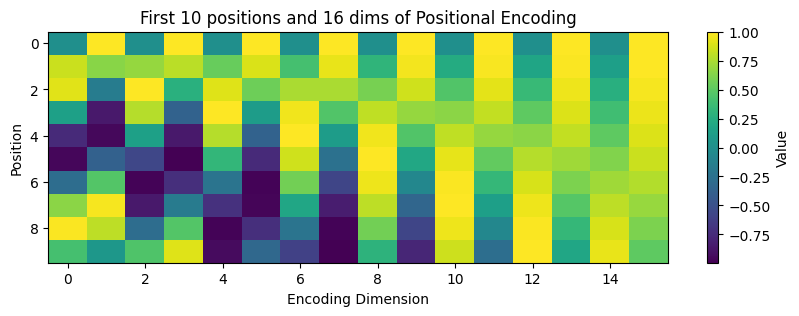

In [ ]:
# Already created:
pos_encoding = get_positional_encoding(max_seq_len, d_model)
print("Positional encoding shape:", pos_encoding.shape)

# Let's view some values!
print("\nFirst 5 rows of positional encoding (first 8 dims):\n")
for i in range(5):
    # Print only the first 8 values for each position for readability
    print(f"Position {i}: {pos_encoding[i, :8].numpy()}")

# Optionally, also visualize as a heatmap (run in a Jupyter notebook with matplotlib):
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))
plt.title("First 10 positions and 16 dims of Positional Encoding")
plt.imshow(pos_encoding[:10, :16].numpy(), aspect='auto', cmap='viridis')
plt.xlabel("Encoding Dimension")
plt.ylabel("Position")
plt.colorbar(label="Value")
plt.show()

# Core Attention Mechanisms

In [ ]:
def scaled_dot_product_attention(q, k, v, mask=None):
    """Compute scaled dot-product attention"""
    d_k = tf.cast(tf.shape(k)[-1], tf.float32)

    # Calculate attention scores
    scores = tf.matmul(q, k, transpose_b=True)
    scores = scores / tf.math.sqrt(d_k)

    # Apply mask if provided
    if mask is not None:
        scores = scores + (mask * -1e9)

    # Apply softmax
    attention_weights = tf.nn.softmax(scores, axis=-1)

    # Apply attention to values
    output = tf.matmul(attention_weights, v)

    return output, attention_weights

def multi_head_attention(queries, keys, values, wq, wk, wv, wo, mask=None):
    """Multi-head attention mechanism"""
    batch_size = tf.shape(queries)[0]
    seq_len_q = tf.shape(queries)[1]
    seq_len_k = tf.shape(keys)[1]
    depth = d_model // num_heads

    # Linear projections
    q = tf.matmul(queries, wq)
    k = tf.matmul(keys, wk)
    v = tf.matmul(values, wv)

    # Reshape for multi-head attention
    q = tf.reshape(q, [batch_size, seq_len_q, num_heads, depth])
    k = tf.reshape(k, [batch_size, seq_len_k, num_heads, depth])
    v = tf.reshape(v, [batch_size, seq_len_k, num_heads, depth])

    # Transpose for attention computation
    q = tf.transpose(q, [0, 2, 1, 3])  # [batch, heads, seq_len_q, depth]
    k = tf.transpose(k, [0, 2, 1, 3])  # [batch, heads, seq_len_k, depth]
    v = tf.transpose(v, [0, 2, 1, 3])  # [batch, heads, seq_len_k, depth]

    # Apply attention
    attention_output, attention_weights = scaled_dot_product_attention(q, k, v, mask)

    # Concatenate heads
    attention_output = tf.transpose(attention_output, [0, 2, 1, 3])
    concat_attention = tf.reshape(attention_output, [batch_size, seq_len_q, d_model])

    # Final linear projection
    output = tf.matmul(concat_attention, wo)

    return output, attention_weights

print("Attention functions defined!")

Attention functions defined!


# Feed-Forward and Utility Functions

In [ ]:
def feed_forward_network(x, w1, b1, w2, b2):
    """Position-wise feed-forward network"""
    x1 = tf.nn.relu(tf.matmul(x, w1) + b1)
    output = tf.matmul(x1, w2) + b2
    return output

def layer_norm(x):
    """Simple layer normalization"""
    epsilon = 1e-6
    mean = tf.reduce_mean(x, axis=-1, keepdims=True)
    variance = tf.reduce_mean(tf.square(x - mean), axis=-1, keepdims=True)
    return (x - mean) / tf.sqrt(variance + epsilon)

def create_padding_mask(seq):
    """Create padding mask"""
    # Mask where seq == 0 (padding token)
    mask = tf.cast(tf.equal(seq, 0), tf.float32)
    return mask[:, tf.newaxis, tf.newaxis, :]  # [batch, 1, 1, seq_len]

def create_look_ahead_mask(size):
    """Create look ahead mask for decoder"""
    mask = tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return 1 - mask  # Invert: 1 means masked

print("Utility functions defined!")

Utility functions defined!


# Encoder Components

In [ ]:
def encoder_layer(x, layer_vars, padding_mask=None):
    """Single encoder layer: self-attention + feed-forward"""
    # Multi-head self-attention
    attn_output, attn_weights = multi_head_attention(
        x, x, x, layer_vars['wq'], layer_vars['wk'], layer_vars['wv'],
        layer_vars['wo'], padding_mask
    )

    # Add & Norm
    x1 = layer_norm(x + attn_output)

    # Feed-forward
    ff_output = feed_forward_network(
        x1, layer_vars['ff_w1'], layer_vars['ff_b1'],
        layer_vars['ff_w2'], layer_vars['ff_b2']
    )

    # Add & Norm
    output = layer_norm(x1 + ff_output)

    return output, attn_weights

def encoder(x, encoder_embedding, encoder_layers_vars):
    """Complete encoder stack"""
    batch_size = tf.shape(x)[0]
    seq_len = tf.shape(x)[1]

    # Embedding
    x = tf.nn.embedding_lookup(encoder_embedding, x)
    x = x * tf.math.sqrt(tf.cast(d_model, tf.float32))  # Scale embeddings

    # Add positional encoding
    x = x + pos_encoding[:seq_len, :]

    # Create padding mask (simple version - mask padding tokens)
    padding_mask = create_padding_mask(tf.argmax(x, axis=-1, output_type=tf.int32))

    # Apply encoder layers
    for layer_vars in encoder_layers_vars:
        x, _ = encoder_layer(x, layer_vars, padding_mask)

    return x

print("Encoder functions defined!")

Encoder functions defined!


# Decoder Components

In [ ]:
def decoder_layer(x, enc_output, layer_vars, look_ahead_mask=None, padding_mask=None):
    """Single decoder layer: masked self-attention + cross-attention + feed-forward"""
    # Masked self-attention
    self_attn_output, self_attn_weights = multi_head_attention(
        x, x, x, layer_vars['self_wq'], layer_vars['self_wk'],
        layer_vars['self_wv'], layer_vars['self_wo'], look_ahead_mask
    )

    # Add & Norm
    x1 = layer_norm(x + self_attn_output)

    # Cross-attention
    cross_attn_output, cross_attn_weights = multi_head_attention(
        x1, enc_output, enc_output, layer_vars['cross_wq'], layer_vars['cross_wk'],
        layer_vars['cross_wv'], layer_vars['cross_wo'], padding_mask
    )

    # Add & Norm
    x2 = layer_norm(x1 + cross_attn_output)

    # Feed-forward
    ff_output = feed_forward_network(
        x2, layer_vars['ff_w1'], layer_vars['ff_b1'],
        layer_vars['ff_w2'], layer_vars['ff_b2']
    )

    # Add & Norm
    output = layer_norm(x2 + ff_output)

    return output, (self_attn_weights, cross_attn_weights)

def decoder(x, enc_output, encoder_input, decoder_embedding, decoder_layers_vars):
    """Complete decoder stack"""
    batch_size = tf.shape(x)[0]
    seq_len = tf.shape(x)[1]

    # Embedding
    x = tf.nn.embedding_lookup(decoder_embedding, x)
    x = x * tf.math.sqrt(tf.cast(d_model, tf.float32))  # Scale embeddings

    # Add positional encoding
    x = x + pos_encoding[:seq_len, :]

    # Create masks
    look_ahead_mask = create_look_ahead_mask(seq_len)
    padding_mask = create_padding_mask(encoder_input)

    # Apply decoder layers
    for layer_vars in decoder_layers_vars:
        x, _ = decoder_layer(x, enc_output, layer_vars, look_ahead_mask, padding_mask)

    return x

print("Decoder functions defined!")

Decoder functions defined!


# Model Variables Initialization

In [ ]:
def initialize_all_variables():
    """Initialize all model variables"""
    variables = {}

    # Embedding matrices
    variables['encoder_embedding'] = tf.Variable(
        tf.random.normal([vocab_size, d_model], stddev=0.1),
        trainable=True, name="encoder_embedding"
    )
    variables['decoder_embedding'] = tf.Variable(
        tf.random.normal([vocab_size, d_model], stddev=0.1),
        trainable=True, name="decoder_embedding"
    )

    # Encoder layers
    variables['encoder_layers'] = []
    for i in range(num_layers):
        layer = {
            'wq': tf.Variable(tf.random.normal([d_model, d_model], stddev=0.1),
                            trainable=True, name=f"enc_layer_{i}_wq"),
            'wk': tf.Variable(tf.random.normal([d_model, d_model], stddev=0.1),
                            trainable=True, name=f"enc_layer_{i}_wk"),
            'wv': tf.Variable(tf.random.normal([d_model, d_model], stddev=0.1),
                            trainable=True, name=f"enc_layer_{i}_wv"),
            'wo': tf.Variable(tf.random.normal([d_model, d_model], stddev=0.1),
                            trainable=True, name=f"enc_layer_{i}_wo"),
            'ff_w1': tf.Variable(tf.random.normal([d_model, d_ff], stddev=0.1),
                               trainable=True, name=f"enc_layer_{i}_ff_w1"),
            'ff_b1': tf.Variable(tf.zeros([d_ff]),
                               trainable=True, name=f"enc_layer_{i}_ff_b1"),
            'ff_w2': tf.Variable(tf.random.normal([d_ff, d_model], stddev=0.1),
                               trainable=True, name=f"enc_layer_{i}_ff_w2"),
            'ff_b2': tf.Variable(tf.zeros([d_model]),
                               trainable=True, name=f"enc_layer_{i}_ff_b2")
        }
        variables['encoder_layers'].append(layer)

    # Decoder layers
    variables['decoder_layers'] = []
    for i in range(num_layers):
        layer = {
            # Self attention
            'self_wq': tf.Variable(tf.random.normal([d_model, d_model], stddev=0.1),
                                 trainable=True, name=f"dec_layer_{i}_self_wq"),
            'self_wk': tf.Variable(tf.random.normal([d_model, d_model], stddev=0.1),
                                 trainable=True, name=f"dec_layer_{i}_self_wk"),
            'self_wv': tf.Variable(tf.random.normal([d_model, d_model], stddev=0.1),
                                 trainable=True, name=f"dec_layer_{i}_self_wv"),
            'self_wo': tf.Variable(tf.random.normal([d_model, d_model], stddev=0.1),
                                 trainable=True, name=f"dec_layer_{i}_self_wo"),
            # Cross attention
            'cross_wq': tf.Variable(tf.random.normal([d_model, d_model], stddev=0.1),
                                  trainable=True, name=f"dec_layer_{i}_cross_wq"),
            'cross_wk': tf.Variable(tf.random.normal([d_model, d_model], stddev=0.1),
                                  trainable=True, name=f"dec_layer_{i}_cross_wk"),
            'cross_wv': tf.Variable(tf.random.normal([d_model, d_model], stddev=0.1),
                                  trainable=True, name=f"dec_layer_{i}_cross_wv"),
            'cross_wo': tf.Variable(tf.random.normal([d_model, d_model], stddev=0.1),
                                  trainable=True, name=f"dec_layer_{i}_cross_wo"),
            # Feed forward
            'ff_w1': tf.Variable(tf.random.normal([d_model, d_ff], stddev=0.1),
                               trainable=True, name=f"dec_layer_{i}_ff_w1"),
            'ff_b1': tf.Variable(tf.zeros([d_ff]),
                               trainable=True, name=f"dec_layer_{i}_ff_b1"),
            'ff_w2': tf.Variable(tf.random.normal([d_ff, d_model], stddev=0.1),
                               trainable=True, name=f"dec_layer_{i}_ff_w2"),
            'ff_b2': tf.Variable(tf.zeros([d_model]),
                               trainable=True, name=f"dec_layer_{i}_ff_b2")
        }
        variables['decoder_layers'].append(layer)

    # Output projection
    variables['output_w'] = tf.Variable(tf.random.normal([d_model, vocab_size], stddev=0.1),
                              trainable=True, name="output_w")
    variables['output_b'] = tf.Variable(tf.zeros([vocab_size]),
                              trainable=True, name="output_b")

    return variables

# Initialize all variables
model_vars = initialize_all_variables()
print("All model variables initialized!")
print(f"Total encoder layers: {len(model_vars['encoder_layers'])}")
print(f"Total decoder layers: {len(model_vars['decoder_layers'])}")

All model variables initialized!
Total encoder layers: 2
Total decoder layers: 2


# Training Functions

In [ ]:
def transformer_forward(encoder_input, decoder_input, model_vars):
    """Forward pass through the transformer"""
    # Encoder
    enc_output = encoder(encoder_input, model_vars['encoder_embedding'], model_vars['encoder_layers'])

    # Decoder
    dec_output = decoder(decoder_input, enc_output, encoder_input,
                        model_vars['decoder_embedding'], model_vars['decoder_layers'])

    # Output projection
    logits = tf.matmul(dec_output, model_vars['output_w']) + model_vars['output_b']

    return logits

def compute_loss(logits, targets):
    """Compute masked cross-entropy loss"""
    # Create mask to ignore padding tokens
    mask = tf.cast(tf.not_equal(targets, 0), tf.float32)

    # Compute loss
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(
        labels=targets, logits=logits
    )

    # Apply mask and compute mean
    masked_loss = loss * mask
    return tf.reduce_sum(masked_loss) / tf.maximum(tf.reduce_sum(mask), 1.0)

def get_all_trainable_variables(model_vars):
    """Get all trainable variables as a flat list"""
    all_vars = []

    # Add embedding variables
    all_vars.extend([model_vars['encoder_embedding'], model_vars['decoder_embedding']])

    # Add encoder variables
    for layer in model_vars['encoder_layers']:
        all_vars.extend(list(layer.values()))

    # Add decoder variables
    for layer in model_vars['decoder_layers']:
        all_vars.extend(list(layer.values()))

    # Add output variables
    all_vars.extend([model_vars['output_w'], model_vars['output_b']])

    return all_vars

@tf.function
def train_step(encoder_input, decoder_input, decoder_target, model_vars, optimizer):
    """Single training step with tf.function for speed"""
    with tf.GradientTape() as tape:
        # Forward pass
        logits = transformer_forward(encoder_input, decoder_input, model_vars)

        # Compute loss
        loss = compute_loss(logits, decoder_target)

    # Get all trainable variables
    all_vars = get_all_trainable_variables(model_vars)

    # Compute gradients
    gradients = tape.gradient(loss, all_vars)

    # Apply gradients
    optimizer.apply_gradients(zip(gradients, all_vars))

    return loss, logits

print("Training functions defined!")

Training functions defined!


# Main Training Loop

In [ ]:
def train_transformer():
    """Main training function"""
    print("Creating training data...")
    english_tokens, target_tokens = create_sample_data()

    print("English tokens shape:", english_tokens.shape)
    print("Target tokens shape:", target_tokens.shape)
    print("\nSample data:")
    for i in range(2):
        print(f"English: {english_tokens[i]}")
        print(f"Target: {target_tokens[i]}")
        print()

    # Prepare decoder input and target
    decoder_input, decoder_target = prepare_decoder_input_target(target_tokens)

    print("Decoder input shape:", decoder_input.shape)
    print("Decoder target shape:", decoder_target.shape)

    # Initialize optimizer
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    # Convert to tensors
    english_tokens = tf.constant(english_tokens)
    decoder_input = tf.constant(decoder_input)
    decoder_target = tf.constant(decoder_target)

    print("\nStarting training...")
    num_epochs = 200

    for epoch in range(num_epochs):
        epoch_loss = 0
        num_examples = english_tokens.shape[0]

        for i in range(num_examples):
            # Get single example
            enc_input = english_tokens[i:i+1]
            dec_input = decoder_input[i:i+1]
            dec_target = decoder_target[i:i+1]

            # Training step
            loss, logits = train_step(enc_input, dec_input, dec_target, model_vars, optimizer)
            epoch_loss += loss

            # Print predictions for first example occasionally
            if i == 0 and epoch % 50 == 0:
                predictions = tf.argmax(logits[0], axis=-1)
                print(f"Epoch {epoch}, Example 0:")
                eng_words = [english_vocab[idx] for idx in enc_input[0].numpy()
                           if idx < len(english_vocab) and english_vocab[idx] != '<pad>']
                tgt_words = [target_vocab[idx] for idx in dec_target[0].numpy()
                           if idx < len(target_vocab) and target_vocab[idx] != '<pad>']
                pred_words = [target_vocab[idx] for idx in predictions.numpy()
                            if idx < len(target_vocab) and target_vocab[idx] != '<pad>']

                print(f"  Input: {eng_words}")
                print(f"  Target: {tgt_words}")
                print(f"  Prediction: {pred_words}")
                print(f"  Loss: {loss:.4f}")
                print()

        if epoch % 50 == 0:
            avg_loss = epoch_loss / num_examples
            print(f"Epoch {epoch}: Average Loss = {avg_loss:.4f}")

    print("Training completed!")
    return model_vars

# Run the training
print("=== TRANSFORMER TRAINING ===")
trained_model_vars = train_transformer()

=== TRANSFORMER TRAINING ===
Creating training data...
English tokens shape: (6, 20)
Target tokens shape: (6, 20)

Sample data:
English: [1 3 4 5 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Target: [1 3 4 5 6 7 2 0 0 0 0 0 0 0 0 0 0 0 0 0]

English: [1 3 4 6 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Target: [1 3 8 5 6 7 2 0 0 0 0 0 0 0 0 0 0 0 0 0]

Decoder input shape: (6, 19)
Decoder target shape: (6, 19)

Starting training...
Epoch 0, Example 0:
  Input: ['<bos>', 'i', 'like', 'cats', '<eos>']
  Target: ['میں', 'بلیاں', 'پسند', 'کرتا', 'ہوں', '<eos>']
  Prediction: ['کتے', 'کتے', 'کتے', 'کتے', 'کتے', 'کتے', 'کتے', 'کتے', 'کتے', 'کتے', 'کتے', 'کتے', 'کتے', 'کتے', 'کتے', 'کتے', 'کتے', 'کتے', 'کتے']
  Loss: 3.5990

Epoch 0: Average Loss = 2.9576
Epoch 50, Example 0:
  Input: ['<bos>', 'i', 'like', 'cats', '<eos>']
  Target: ['میں', 'بلیاں', 'پسند', 'کرتا', 'ہوں', '<eos>']
  Prediction: ['میں', 'بلیاں', 'پسند', 'کرتا', 'ہوں', '<eos>', '<eos>', 'ہوں', '<eos>', '<eos>', '<eos>', '<eos>', '<eos>', '<eos>', '<

# Translation/Inference Function

In [ ]:
def simple_translate(input_sentence, model_vars):
    """Simple translation function for demonstration"""
    print(f"\nTranslating: '{input_sentence}'")

    # Tokenize input
    input_tokens = tokenize_sentence(input_sentence, english_word_to_idx)
    encoder_input = tf.constant([input_tokens])

    # Start with BOS token for decoder
    decoder_input = [target_word_to_idx["<bos>"]]

    # Generate tokens one by one (greedy decoding)
    for _ in range(max_seq_len - 1):
        # Pad decoder input to match expected shape
        current_input = decoder_input + [0] * (max_seq_len - 1 - len(decoder_input))
        current_input = current_input[:max_seq_len - 1]  # Ensure correct length

        decoder_input_tensor = tf.constant([current_input])

        # Get predictions
        logits = transformer_forward(encoder_input, decoder_input_tensor, model_vars)

        # Get next token (last meaningful position)
        next_token_logits = logits[0, len(decoder_input) - 1, :]
        next_token = tf.argmax(next_token_logits)
        next_token_idx = int(next_token.numpy())

        # Stop if EOS token or padding
        if next_token_idx == target_word_to_idx["<eos>"] or next_token_idx == 0:
            break

        # Add to sequence
        decoder_input.append(next_token_idx)

    # Convert back to words (skip BOS)
    translated_words = []
    for idx in decoder_input[1:]:
        if idx < len(target_vocab) and target_vocab[idx] not in ["<eos>", "<pad>"]:
            translated_words.append(target_vocab[idx])

    return " ".join(translated_words)

print("Translation function defined!")

Translation function defined!


# Execute Training and Testing

In [ ]:
print("=== TESTING TRANSLATION ===")
print("Training completed! Testing the model...")

# Test some translations
test_sentences = ["i like cats", "i am happy", "cats like dogs", "i like dogs"]

print("\nTranslation Results:")
print("-" * 40)
for sentence in test_sentences:
    try:
        translation = simple_translate(sentence, trained_model_vars)
        print(f"'{sentence}' -> '{translation}'")
    except Exception as e:
        print(f"Error translating '{sentence}': {e}")

print("\n" + "=" * 50)
print("TRANSFORMER TRAINING AND TESTING COMPLETE!")
print("=" * 50)

print("\nModel Summary:")
print(f"- Vocabulary size: {vocab_size}")
print(f"- Model dimension: {d_model}")
print(f"- Number of heads: {num_heads}")
print(f"- Number of layers: {num_layers}")
print(f"- Feed-forward dimension: {d_ff}")
print(f"- Max sequence length: {max_seq_len}")


print("\nThis is an educational Transformer implementation!")

=== TESTING TRANSLATION ===
Training completed! Testing the model...

Translation Results:
----------------------------------------

Translating: 'i like cats'
'i like cats' -> 'میں بلیاں پسند کرتا ہوں'

Translating: 'i am happy'
'i am happy' -> 'میں خوش ہوں'

Translating: 'cats like dogs'
'cats like dogs' -> 'بلیاں کتے پسند ہیں'

Translating: 'i like dogs'
'i like dogs' -> 'میں کتے پسند کرتا ہوں'

TRANSFORMER TRAINING AND TESTING COMPLETE!

Model Summary:
- Vocabulary size: 12
- Model dimension: 128
- Number of heads: 8
- Number of layers: 2
- Feed-forward dimension: 512
- Max sequence length: 20

This is an educational Transformer implementation!
